# LLM prompting implementation

In [3]:

import pandas as pd
import torch
from sklearn.model_selection import train_test_split
import tqdm



### This only applies if user is using Google Drive ###

from google.colab import drive
import os

drive.mount('/content/drive')


# This assumes you have a folder named 'Colab_Project' in your 'My Drive'
DRIVE_PATH = '/content/drive/MyDrive/dataset'

os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"Drive mounted and directory checked at: {DRIVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and directory checked at: /content/drive/MyDrive/dataset


In [4]:
dataset_path = f'{DRIVE_PATH}/test_data.csv'
df = pd.read_csv(dataset_path)

CLARITY_LABEL = 'Clear Non-Reply'

AMB_CLASSES = ['Implicit', 'Dodging', 'General', 'Deflection', 'Partial/half-answer']
CN_CLASSES = ['Declining to answer', 'Claims Ignorance', 'Clarification']

CLASSES = CN_CLASSES
print(print(df.isnull().sum()))

title                    308
date                     308
president                308
url                        0
question_order             0
interview_question         0
interview_answer           0
gpt3.5_summary           308
gpt3.5_prediction        308
question                   0
annotator_id             308
annotator1                 0
annotator2                 0
annotator3                 0
inaudible                  0
multiple_questions         0
affirmative_questions      0
index                      0
clarity_label              0
evasion_label            308
dtype: int64
None


In [5]:

from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen3-4B-Instruct-2507"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

prompt = "Give me a short introduction to large language model."

messages = [
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# conduct text completion
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=16384
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

content = tokenizer.decode(output_ids, skip_special_tokens=True)

print("content:", content)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/3.96G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

content: A large language model (LLM) is a type of artificial intelligence system trained on vast amounts of text data to understand and generate human-like language. These models consist of billions of parameters and are designed to recognize patterns in language, enabling them to answer questions, write stories, code, and perform various natural language tasks. By using deep learning techniques, especially transformer architectures, LLMs can generate coherent and contextually relevant responses based on the input they receive. Examples include GPT, BERT, and Llama. While powerful, they require significant computational resources and must be used with care to ensure accuracy, fairness, and ethical considerations.


In [6]:

label_list = ", ".join(CLASSES)

SYSTEM_PROMPT = f"""
You are a political-analysis classifier. You analyze a politician’s response to an interview question.
For each input, you will be given a Question and an Answer.
Your task is to output exactly one evasion label, with no explanation or additional text.
The possible labels are: {label_list}
"""


In [7]:
SYSTEM_PROMPT_CLARITY = """You are a political-analysis classifier. You analyze a politician’s response to an interview question. For each input, you will be given a Question and an Answer.
Your task is to output exactly one label, with no explanation or additional text. The three possible labels are: Ambivalent, Clear Non-Reply or Clear Reply"

**Clear Reply**: The answer directly addresses the question with a specific position or factual information.

**Clear Non-Reply**: The answer completely avoids or deflects the question without engaging with its substance.

**Ambivalent**: The answer partially addresses the question but hedges, qualifies, or presents multiple contradictory positions without committing to one.

Examples:
Q: "Do you support the tax increase?"
A: "Well, taxes are complicated. We need to balance fiscal responsibility with social needs." → Ambivalent

Q: "Do you support the tax increase?"
A: "Yes, I support it." → Clear Reply

Q: "Do you support the tax increase?"
A: "Let me tell you about my record on job creation." → Clear Non-Reply

Output only the label, nothing else."""



FEW_SHOT_EXAMPLES_AMB = """

Definitions:

**Implicit**: The answer indirectly addresses the question by implication or suggestion, without stating a clear position. The response alludes to the topic but avoids explicitly answering.

**Dodging**: The answer avoids the question entirely by changing the topic, giving irrelevant information, or refusing to engage with the substance of the question.

**General**: The answer gives broad, generic statements that could apply to many situations, without providing concrete information or a clear stance.

**Deflection**: The answer shifts responsibility or focus away from the politician—often toward other individuals, institutions, or contextual factors—rather than addressing the question.

**Partial/half-answer**: The answer addresses part of the question but leaves key elements unanswered, offering an incomplete or insufficiently specific response.

Examples:

Q: "Do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?"
A: "The President expresses sincerity about getting the relationship between the United States and China right. 2. China is changing some of the rules of the game, such as banning Chinese government officials from using Western cell phones. 3. The purpose of the trip was not to contain China but to establish a stable relationship with China and strengthen alliances in the Indo-Pacific region. 4. The Quad (Australia, India, Japan, and United States) is not meant to isolate China but to maintain stability and ensure that international rules are followed. 5. President Xi has some economic difficulties, and the President hopes to see China succeed economically while also following the rules."
→ General

Q: "Would President Biden be willing to talk with Tuberville to find a solution?"
A: "President Biden expresses his willingness to engage in a conversation with Senator Tuberville, but only if there is a possibility of him changing his position. He criticizes Tuberville's stance as irresponsible and emphasizes the need for the mainstream Republican Party to take a stand against it."
→ Deflection

Q: "Do you believe the country's slowdown and growth could risk destabilizing the global economy or cause China to be more aggressive defensively, including with Taiwan?"
A: "- The President acknowledges that China has a difficult economic problem due to international growth issues and the policies they have followed. - The response suggests that China's economic difficulties are unlikely to lead to an invasion of Taiwan. In fact, it states that China may not have the same capacity as before. - The President emphasizes that the goal is not to harm China, and that it is beneficial for both countries if China does well and follows international rules. - The President mentions China's difficulties in real estate and indicates that China is in the process of deciding on actions to address these challenges. The outcome of these actions is uncertain."
→ Partial/half-answer

Q: "Regarding Korean businesses' concerns about the CHIPS Act and the IRA, what message can President Biden send to reassure them?"
A: "- The response provides that the technology cooperation and partnerships in cutting-edge industries will enhance the competitiveness, productivity, and create high added value products in both countries. - The public will benefit from job creation and comprehensive benefits resulting from the industries and investments. - Future generations will be motivated and empowered to take on new challenges and opportunities in the industry."
→ Implicit

Q: "Are you missing in action?"
A: "- The response does not directly address this question part and does not provide any information regarding being missing in action."
→ Dodging

Output only the label, nothing else.

"""

FEW_SHOT_EXAMPLES_NON = """
Definitions:

**Declining to answer**: The politician explicitly refuses to answer, avoids giving a position, or states that they will not comment or cannot answer the question at this time.

**Claims Ignorance**: The politician says they do not know, are not aware, lack the necessary information, or cannot comment due to insufficient knowledge.

**Clarification**: The politician requests clarification, asks the interviewer to restate or refine the question, or indicates they need more detail before responding.

Examples:

Q: "Did you authorize the budget changes last quarter?"
A: "I won't comment on that at this moment."
→ Declining to answer

Q: "Did you authorize the budget changes last quarter?"
A: "I'm not aware of the specific decisions that were made at that level."
→ Claims Ignorance

Q: "Did you authorize the budget changes last quarter?"
A: "Could you specify which changes you're referring to?"
→ Clarification

Output only the label, nothing else.


"""



In [8]:
def get_labels(question, full_answer, SYSTEM_PROMPT=SYSTEM_PROMPT, EXAMPLES=FEW_SHOT_EXAMPLES_NON):

    # New user prompt with examples + target case
    user_prompt = f"""
You will first see some examples with their correct labels. After that, classify a new case.

{EXAMPLES}

Now classify the following new example.

Subquestion: "{question}"

Full Interview Answer:
---
{full_answer}
---

Evasion label (one of {", ".join(CLASSES)}):
"""

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=8,   # we only need a single label, not 16k tokens
        do_sample=False,
        temperature=0.0,
    )
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

    content = tokenizer.decode(output_ids, skip_special_tokens=True).strip()

    return content



# Example test before running on the full dataframe
test_q = "What is the policy?"
test_a = "Our policy is clearly defined in section 3. We updated it last year after feedback."
print(f"Label: {get_labels(test_q, test_a, SYSTEM_PROMPT)}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Label: Clarification


Filter out data

In [9]:
df_filtered = df[df["clarity_label"] == CLARITY_LABEL]

In [10]:
import os
from tqdm.auto import tqdm

processed_df = df_filtered.copy()
processed_df['evasion_label_LLM'] = None  # Initialize a new column

DISPLAY_INTERVAL = 5


start_index = 0

print(f"Starting extraction from entry {start_index} of {len(processed_df)}")

for index, row in tqdm(
    processed_df.iloc[start_index:].iterrows(),
    total=len(processed_df.iloc[start_index:])
):
    question = row['question']
    interview_answer = row['interview_answer']

    extracted_text = get_labels(question, interview_answer, SYSTEM_PROMPT)
    processed_df.at[index, 'evasion_label_LLM'] = extracted_text

    if (index + 1) % DISPLAY_INTERVAL == 0:
        print(f"\n--- Sample Display at Entry {index + 1} ---")
        print(f"Question: {question[:100]}...")
        print(f"Full Answer (Snippet): {interview_answer[:150]}...")
        print(f"**Evasion label (LLM):** {extracted_text}")
        # assuming your ground-truth label column is called 'clarity_label'
        print(f"**True label:** {row['evasion_label']}")
        print("------------------------------------------")

print("Processing complete!")

FINAL_FILE_NAME = 'test_data_evasion_label_LLM_non.csv'
processed_df.to_csv(FINAL_FILE_NAME, index=False)
print(f"Final data saved to {FINAL_FILE_NAME}")

Starting extraction from entry 0 of 23


  0%|          | 0/23 [00:00<?, ?it/s]


--- Sample Display at Entry 30 ---
Question: Mr. President, if the EU does not receive a definitive answer from Iran on the incentives package by...
Full Answer (Snippet): I said I wasn't going to answer a hypothetical; now you're trying to get me to answer a hypothetical. The G-8 will be an opportunity for those of us i...
**Evasion label (LLM):** Declining to answer
**True label:** nan
------------------------------------------

--- Sample Display at Entry 50 ---
Question: Will the prison close?...
Full Answer (Snippet): Well, I haven't had a chance to fully review what the Court said, Terry. I wish I had, and I could have given you a better answer. As I say, we take t...
**Evasion label (LLM):** Claims Ignorance
**True label:** nan
------------------------------------------

--- Sample Display at Entry 85 ---
Question: Can you now tell us, where was it headed?...
Full Answer (Snippet): I still can't give you any better answer than yesterday. I can embellish yesterday's answer. It m

In [11]:
import pandas as pd

df = pd.read_csv("/content/test_data_evasion_label_LLM_non.csv")

LLM_COL = "evasion_label_LLM"
ANNOTATOR_COLS = ["annotator1", "annotator2", "annotator3"]  # change to your names

# Clean up text labels
df[LLM_COL] = df[LLM_COL].astype(str).str.strip()
for col in ANNOTATOR_COLS:
    df[col] = df[col].astype(str).str.strip()



Confusion Matrix vs annotator1


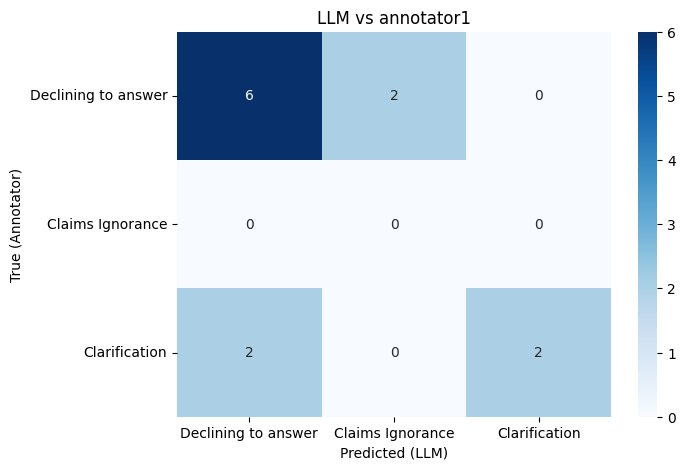


Confusion Matrix vs annotator2


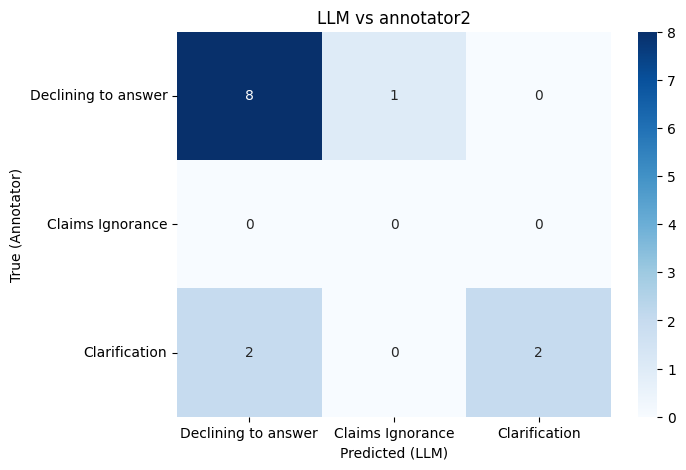


Confusion Matrix vs annotator3


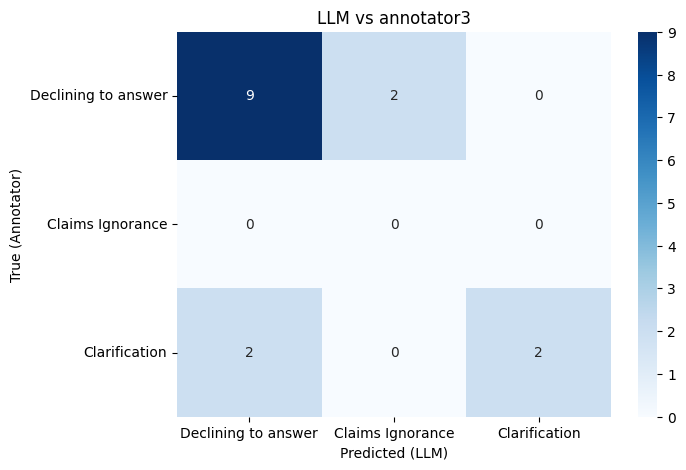

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

CLASSES = CN_CLASSES

def plot_cm(cm, title):
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title)
    plt.xlabel("Predicted (LLM)")
    plt.ylabel("True (Annotator)")
    plt.show()

for ann in ANNOTATOR_COLS:
    cm = confusion_matrix(df[ann], df[LLM_COL], labels=CLASSES)
    print(f"\nConfusion Matrix vs {ann}")
    plot_cm(cm, f"LLM vs {ann}")

Comparing against each annotator

In [13]:
from collections import Counter

def majority_vote(row):
    votes = [row[col] for col in ANNOTATOR_COLS]
    most_common, count = Counter(votes).most_common(1)[0]
    return most_common

df["gold_label"] = df.apply(majority_vote, axis=1)

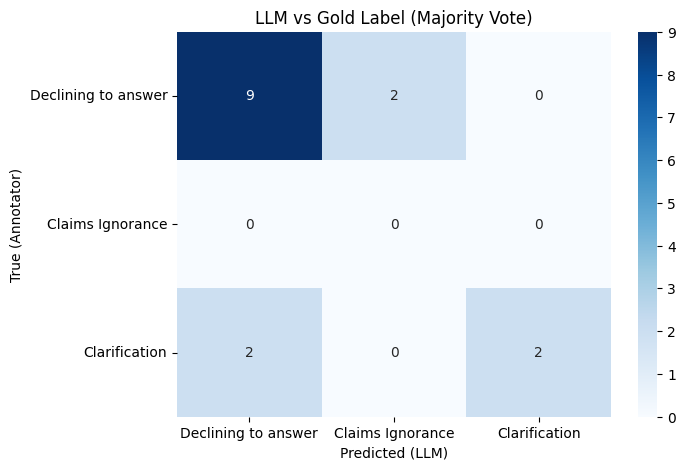

In [14]:
cm = confusion_matrix(df["gold_label"], df[LLM_COL], labels=CLASSES)
plot_cm(cm, "LLM vs Gold Label (Majority Vote)")

In [15]:
from sklearn.metrics import classification_report
print(classification_report(df["gold_label"], df[LLM_COL], labels=CLASSES, digits=3))

                     precision    recall  f1-score   support

Declining to answer      0.692     0.818     0.750        11
   Claims Ignorance      0.000     0.000     0.000         0
      Clarification      1.000     0.500     0.667         4

          micro avg      0.478     0.733     0.579        15
          macro avg      0.564     0.439     0.472        15
       weighted avg      0.774     0.733     0.728        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
def match_any_annotator(row):
    llm = row[LLM_COL]
    ann_labels = [row[col] for col in ANNOTATOR_COLS]
    return llm in ann_labels

df["correct_any"] = df.apply(match_any_annotator, axis=1)

accuracy_any = df["correct_any"].mean()
print(f"Accuracy (LLM matches ANY annotator): {accuracy_any:.3f}")

Accuracy (LLM matches ANY annotator): 0.522
